# 07 - Model Evaluation

## Objective

The purpose of this notebook is to evaluate the candidate machine learning
models trained in the previous notebook.

The project predicts five health risk scores:

- Diabetes Risk Score
- Hypertension Risk Score
- Heart Disease Risk Score
- Obesity Risk Score
- Cholesterol Risk Score

The following regression models will be evaluated:

- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

The models will be evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The evaluation will be performed separately for each target variable.

The best-performing model will then be selected for each health risk score.

In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
#load test data

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
)

print("Test data loaded successfully.")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Test data loaded successfully.
X_test shape: (19460, 36)
y_test shape: (19460, 5)


In [3]:
#Check target variables

target_columns = y_test.columns.tolist()

print("Target variables:")

for target in target_columns:
    print("-", target)

Target variables:
- diabetes_risk_score
- hypertension_risk_score
- heart_disease_risk_score
- obesity_risk_score
- cholesterol_risk_score


In [4]:
print("\nTarget statistics:")
display(y_test.describe())


Target statistics:


,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
count,19460.000000,19460.000000,19460.000000,19460.000000,19460.000000
mean,41.234087,41.183042,32.054408,48.453646,26.053706
std,11.002048,12.734954,15.441100,11.067067,13.098245
min,1.821211,1.777867,0.000000,12.861417,0.000000
25%,33.623072,32.224442,20.331161,40.881553,16.425136
50%,40.812247,41.067048,30.754303,48.553341,25.502118
75%,48.394077,50.012153,42.457352,56.086839,34.749743
max,81.592921,86.623981,97.902483,84.299987,83.112231


In [5]:
#Load preprocessing pipeline

preprocessing_pipeline = joblib.load(
    "../models/preprocessing_pipeline.pkl"
)

print("Preprocessing pipeline loaded successfully.")

Preprocessing pipeline loaded successfully.


In [6]:
#Transform test data

X_test_processed = preprocessing_pipeline.transform(
    X_test
)

print("X_test processed successfully.")
print("Processed test shape:", X_test_processed.shape)

X_test processed successfully.
Processed test shape: (19460, 61)


In [7]:
#Load candidate models

candidate_model_dir = "../models/candidates"

model_file_names = {
    "Linear Regression": "linear_regression.pkl",
    "Ridge Regression": "ridge_regression.pkl",
    "Random Forest": "random_forest.pkl",
    "Gradient Boosting": "gradient_boosting.pkl",
    "Extra Trees": "extra_trees.pkl"
}

In [8]:
candidate_models = {}

for model_name, file_name in model_file_names.items():

    file_path = os.path.join(
        candidate_model_dir,
        file_name
    )

    candidate_models[model_name] = joblib.load(
        file_path
    )

    print(f"{model_name} loaded successfully.")

Linear Regression loaded successfully.
Ridge Regression loaded successfully.
Random Forest loaded successfully.
Gradient Boosting loaded successfully.
Extra Trees loaded successfully.


In [9]:
#Check loaded models

print("Candidate models:")

for model_name in candidate_models:
    print("-", model_name)

Candidate models:
- Linear Regression
- Ridge Regression
- Random Forest
- Gradient Boosting
- Extra Trees


In [10]:
#Generate predictions

predictions = {}

for model_name, model in candidate_models.items():

    print(f"Generating predictions for {model_name}...")

    y_pred = model.predict(
        X_test_processed
    )

    predictions[model_name] = y_pred

    print(
        f"{model_name} prediction shape:",
        y_pred.shape
    )

Generating predictions for Linear Regression...
Linear Regression prediction shape: (19460, 5)
Generating predictions for Ridge Regression...
Ridge Regression prediction shape: (19460, 5)
Generating predictions for Random Forest...
Random Forest prediction shape: (19460, 5)
Generating predictions for Gradient Boosting...
Gradient Boosting prediction shape: (19460, 5)
Generating predictions for Extra Trees...
Extra Trees prediction shape: (19460, 5)


In [11]:
#Verify prediction values

linear_predictions = predictions["Linear Regression"]

linear_predictions_df = pd.DataFrame(
    linear_predictions,
    columns=target_columns
)

linear_predictions_df.head()

,diabetes_risk_score,hypertension_risk_score,heart_disease_risk_score,obesity_risk_score,cholesterol_risk_score
0,24.569111,34.577525,25.149735,43.263745,46.607628
1,57.974127,51.149802,44.211284,45.353610,16.404644
2,39.886204,40.464271,9.269678,72.732240,21.210501
3,24.215075,33.043296,21.846902,29.474476,13.656351
4,41.761133,56.122056,42.588171,51.421233,33.288039


In [12]:
#Compare actual and predicted values

comparison_df = pd.DataFrame()

for target_index, target in enumerate(target_columns):

    comparison_df[f"Actual_{target}"] = (
        y_test[target].values
    )

    comparison_df[f"Predicted_{target}"] = (
        predictions["Linear Regression"][:, target_index]
    )

comparison_df.head()

,Actual_diabetes_risk_score,Predicted_diabetes_risk_score,Actual_hypertension_risk_score,Predicted_hypertension_risk_score,Actual_heart_disease_risk_score,Predicted_heart_disease_risk_score,Actual_obesity_risk_score,Predicted_obesity_risk_score,Actual_cholesterol_risk_score,Predicted_cholesterol_risk_score
0,24.402726,24.569111,34.279777,34.577525,32.207878,25.149735,44.033764,43.263745,47.370814,46.607628
1,58.724192,57.974127,54.354507,51.149802,46.456009,44.211284,45.119112,45.353610,15.713445,16.404644
2,39.740296,39.886204,38.415591,40.464271,6.767757,9.269678,72.596283,72.732240,19.181908,21.210501
3,24.636067,24.215075,33.166145,33.043296,12.408908,21.846902,30.485629,29.474476,14.541816,13.656351
4,43.523157,41.761133,54.801778,56.122056,34.015128,42.588171,53.005629,51.421233,32.742967,33.288039


In [13]:
#Calculate MAE, RMSE and R²

evaluation_results = []

for model_name, y_pred in predictions.items():

    for target_index, target in enumerate(target_columns):

        actual = y_test[target].values
        predicted = y_pred[:, target_index]

        mae = mean_absolute_error(
            actual,
            predicted
        )

        rmse = np.sqrt(
            mean_squared_error(
                actual,
                predicted
            )
        )

        r2 = r2_score(
            actual,
            predicted
        )

        evaluation_results.append({
            "Model": model_name,
            "Target": target,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

In [14]:
#Create evaluation DataFrame

evaluation_df = pd.DataFrame(
    evaluation_results
)

evaluation_df

,Model,Target,MAE,RMSE,R2
0,Linear Regression,diabetes_risk_score,1.714473,2.170258,0.961087
1,Linear Regression,hypertension_risk_score,2.018996,2.533214,0.960430
2,Linear Regression,heart_disease_risk_score,4.149555,5.184019,0.887281
3,Linear Regression,obesity_risk_score,1.373976,1.771350,0.974381
4,Linear Regression,cholesterol_risk_score,1.165006,1.503186,0.986829
5,Ridge Regression,diabetes_risk_score,1.714478,2.170261,0.961087
6,Ridge Regression,hypertension_risk_score,2.018995,2.533213,0.960430
7,Ridge Regression,heart_disease_risk_score,4.149558,5.184019,0.887280
8,Ridge Regression,obesity_risk_score,1.373992,1.771355,0.974381
9,Ridge Regression,cholesterol_risk_score,1.165008,1.503187,0.986829


In [15]:
print("Number of evaluation results:", len(evaluation_df))

Number of evaluation results: 25


In [16]:
#Round the results

evaluation_display = evaluation_df.copy()

evaluation_display[
    ["MAE", "RMSE", "R2"]
] = evaluation_display[
    ["MAE", "RMSE", "R2"]
].round(4)

evaluation_display

,Model,Target,MAE,RMSE,R2
0,Linear Regression,diabetes_risk_score,1.7145,2.1703,0.9611
1,Linear Regression,hypertension_risk_score,2.0190,2.5332,0.9604
2,Linear Regression,heart_disease_risk_score,4.1496,5.1840,0.8873
3,Linear Regression,obesity_risk_score,1.3740,1.7713,0.9744
4,Linear Regression,cholesterol_risk_score,1.1650,1.5032,0.9868
5,Ridge Regression,diabetes_risk_score,1.7145,2.1703,0.9611
6,Ridge Regression,hypertension_risk_score,2.0190,2.5332,0.9604
7,Ridge Regression,heart_disease_risk_score,4.1496,5.1840,0.8873
8,Ridge Regression,obesity_risk_score,1.3740,1.7714,0.9744
9,Ridge Regression,cholesterol_risk_score,1.1650,1.5032,0.9868


In [17]:
#Diabetes evaluation

diabetes_results = evaluation_df[
    evaluation_df["Target"] == "diabetes_risk_score"
].sort_values(
    by="RMSE"
)

diabetes_results

,Model,Target,MAE,RMSE,R2
0,Linear Regression,diabetes_risk_score,1.714473,2.170258,0.961087
5,Ridge Regression,diabetes_risk_score,1.714478,2.170261,0.961087
15,Gradient Boosting,diabetes_risk_score,1.749300,2.190863,0.960344
10,Random Forest,diabetes_risk_score,2.675889,3.393623,0.904851
20,Extra Trees,diabetes_risk_score,2.720196,3.452733,0.901508


In [18]:
#Hypertension evaluation

heart_disease_results = evaluation_df[
    evaluation_df["Target"] == "heart_disease_risk_score"
].sort_values(
    by="RMSE"
)

heart_disease_results

,Model,Target,MAE,RMSE,R2
17,Gradient Boosting,heart_disease_risk_score,3.292623,4.178837,0.926755
22,Extra Trees,heart_disease_risk_score,3.697136,4.637831,0.909781
12,Random Forest,heart_disease_risk_score,3.735227,4.721964,0.906479
2,Linear Regression,heart_disease_risk_score,4.149555,5.184019,0.887281
7,Ridge Regression,heart_disease_risk_score,4.149558,5.184019,0.887280


In [ ]:
#Cholesterol evaluation

cholesterol_results = evaluation_df[
    evaluation_df["Target"] == "cholesterol_risk_score"
].sort_values(
    by="RMSE"
)

cholesterol_results

,Model,Target,MAE,RMSE,R2
19,Gradient Boosting,cholesterol_risk_score,0.930187,1.173354,0.991975
4,Linear Regression,cholesterol_risk_score,1.165006,1.503186,0.986829
9,Ridge Regression,cholesterol_risk_score,1.165008,1.503187,0.986829
24,Extra Trees,cholesterol_risk_score,1.673780,2.215249,0.971395
14,Random Forest,cholesterol_risk_score,2.133359,2.813997,0.953842


In [20]:
#Heart disease evaluation

heart_disease_results = evaluation_df[
    evaluation_df["Target"] == "heart_disease_risk_score"
].sort_values(
    by="RMSE"
)

heart_disease_results

,Model,Target,MAE,RMSE,R2
17,Gradient Boosting,heart_disease_risk_score,3.292623,4.178837,0.926755
22,Extra Trees,heart_disease_risk_score,3.697136,4.637831,0.909781
12,Random Forest,heart_disease_risk_score,3.735227,4.721964,0.906479
2,Linear Regression,heart_disease_risk_score,4.149555,5.184019,0.887281
7,Ridge Regression,heart_disease_risk_score,4.149558,5.184019,0.887280


In [22]:
#Obesity evaluation

obesity_results = evaluation_df[
    evaluation_df["Target"] == "obesity_risk_score"
].sort_values(
    by="RMSE"
)

obesity_results

,Model,Target,MAE,RMSE,R2
18,Gradient Boosting,obesity_risk_score,1.267963,1.592833,0.979284
3,Linear Regression,obesity_risk_score,1.373976,1.771350,0.974381
8,Ridge Regression,obesity_risk_score,1.373992,1.771355,0.974381
13,Random Forest,obesity_risk_score,2.602220,3.305135,0.910806
23,Extra Trees,obesity_risk_score,2.642130,3.341135,0.908852


In [24]:
#Automatically select the best model for each target

best_models = {}

for target in target_columns:

    target_results = evaluation_df[
        evaluation_df["Target"] == target
    ]

    best_row = target_results.loc[
        target_results["RMSE"].idxmin()
    ]

    best_models[target] = {
        "Model": best_row["Model"],
        "MAE": best_row["MAE"],
        "RMSE": best_row["RMSE"],
        "R2": best_row["R2"]
    }

#Display best models

best_models_df = pd.DataFrame(
    best_models
).T

best_models_df    

,Model,MAE,RMSE,R2
diabetes_risk_score,Linear Regression,1.714473,2.170258,0.961087
hypertension_risk_score,Ridge Regression,2.018995,2.533213,0.96043
heart_disease_risk_score,Gradient Boosting,3.292623,4.178837,0.926755
obesity_risk_score,Gradient Boosting,1.267963,1.592833,0.979284
cholesterol_risk_score,Gradient Boosting,0.930187,1.173354,0.991975


In [25]:
#final model selection

print("Best Model for Each Risk Score")

for target, result in best_models.items():

    print(f"\nTarget: {target}")
    print(f"Best Model: {result['Model']}")
    print(f"MAE:  {result['MAE']:.4f}")
    print(f"RMSE: {result['RMSE']:.4f}")
    print(f"R²:   {result['R2']:.4f}")

Best Model for Each Risk Score

Target: diabetes_risk_score
Best Model: Linear Regression
MAE:  1.7145
RMSE: 2.1703
R²:   0.9611

Target: hypertension_risk_score
Best Model: Ridge Regression
MAE:  2.0190
RMSE: 2.5332
R²:   0.9604

Target: heart_disease_risk_score
Best Model: Gradient Boosting
MAE:  3.2926
RMSE: 4.1788
R²:   0.9268

Target: obesity_risk_score
Best Model: Gradient Boosting
MAE:  1.2680
RMSE: 1.5928
R²:   0.9793

Target: cholesterol_risk_score
Best Model: Gradient Boosting
MAE:  0.9302
RMSE: 1.1734
R²:   0.9920


In [26]:
#Model comparison using RMSE

rmse_comparison = evaluation_df.pivot(
    index="Model",
    columns="Target",
    values="RMSE"
)

rmse_comparison

Target,cholesterol_risk_score,diabetes_risk_score,heart_disease_risk_score,hypertension_risk_score,obesity_risk_score
Model,,,,,
Extra Trees,2.215249,3.452733,4.637831,3.353392,3.341135
Gradient Boosting,1.173354,2.190863,4.178837,2.676524,1.592833
Linear Regression,1.503186,2.170258,5.184019,2.533214,1.771350
Random Forest,2.813997,3.393623,4.721964,3.584737,3.305135
Ridge Regression,1.503187,2.170261,5.184019,2.533213,1.771355


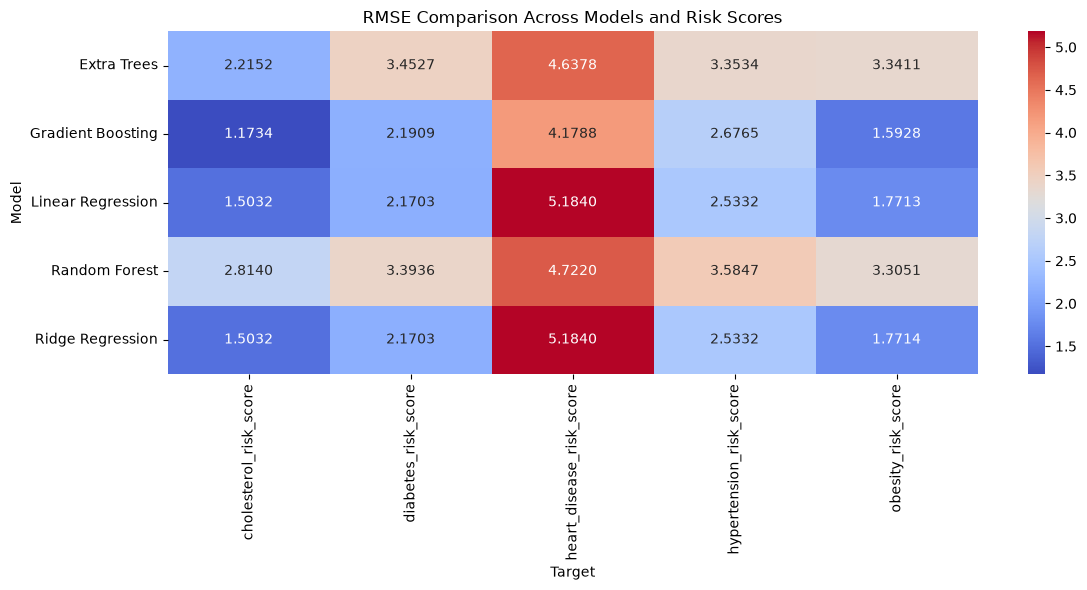

In [27]:
#RMSE comparison heatmap

plt.figure(figsize=(12, 6))

sns.heatmap(
    rmse_comparison,
    annot=True,
    fmt=".4f",
    cmap="coolwarm"
)

plt.title("RMSE Comparison Across Models and Risk Scores")
plt.xlabel("Target")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [28]:
#R² comparison

r2_comparison = evaluation_df.pivot(
    index="Model",
    columns="Target",
    values="R2"
)

r2_comparison

Target,cholesterol_risk_score,diabetes_risk_score,heart_disease_risk_score,hypertension_risk_score,obesity_risk_score
Model,,,,,
Extra Trees,0.971395,0.901508,0.909781,0.930658,0.908852
Gradient Boosting,0.991975,0.960344,0.926755,0.955826,0.979284
Linear Regression,0.986829,0.961087,0.887281,0.960430,0.974381
Random Forest,0.953842,0.904851,0.906479,0.920760,0.910806
Ridge Regression,0.986829,0.961087,0.887280,0.960430,0.974381


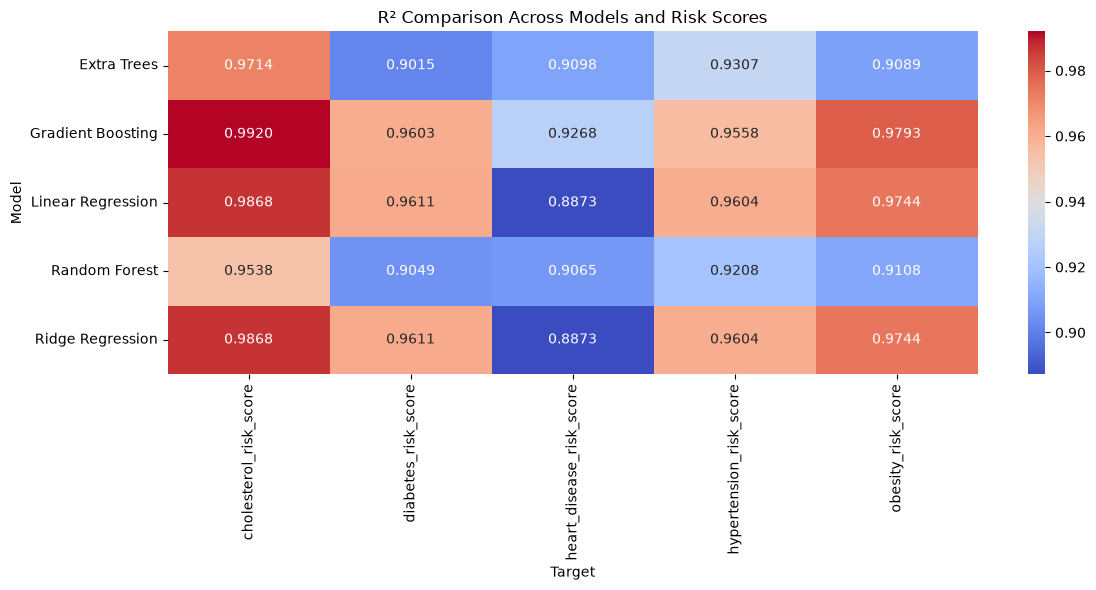

In [29]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    r2_comparison,
    annot=True,
    fmt=".4f",
    cmap="coolwarm"
)

plt.title("R² Comparison Across Models and Risk Scores")
plt.xlabel("Target")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [30]:
#MAE comparison

mae_comparison = evaluation_df.pivot(
    index="Model",
    columns="Target",
    values="MAE"
)

mae_comparison

Target,cholesterol_risk_score,diabetes_risk_score,heart_disease_risk_score,hypertension_risk_score,obesity_risk_score
Model,,,,,
Extra Trees,1.673780,2.720196,3.697136,2.626588,2.642130
Gradient Boosting,0.930187,1.749300,3.292623,2.129815,1.267963
Linear Regression,1.165006,1.714473,4.149555,2.018996,1.373976
Random Forest,2.133359,2.675889,3.735227,2.802264,2.602220
Ridge Regression,1.165008,1.714478,4.149558,2.018995,1.373992


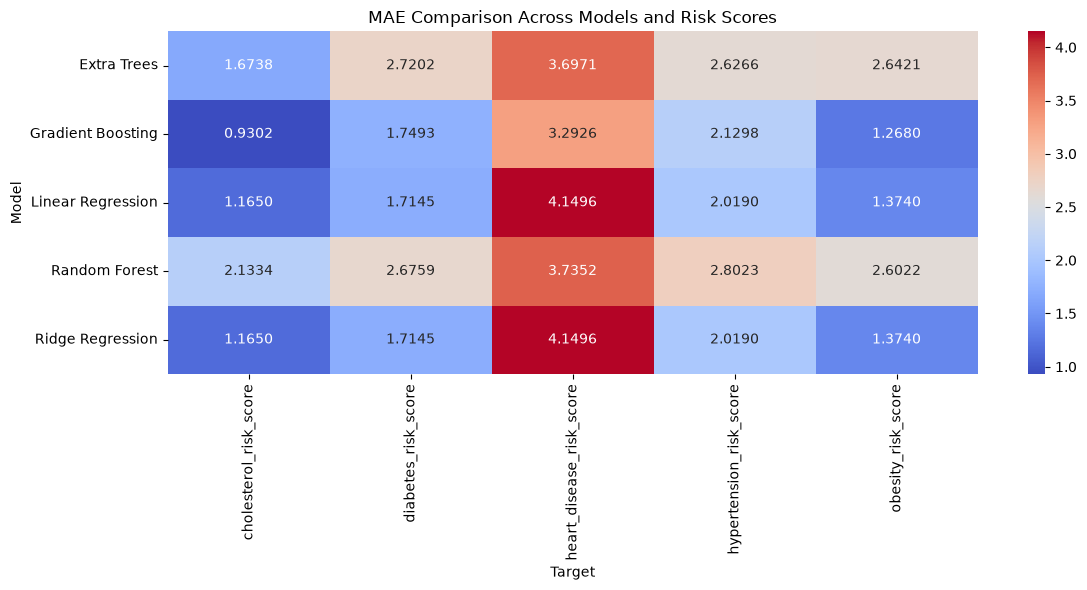

In [31]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    mae_comparison,
    annot=True,
    fmt=".4f",
    cmap="coolwarm"
)

plt.title("MAE Comparison Across Models and Risk Scores")
plt.xlabel("Target")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [32]:
#Overall model performance

overall_model_performance = (
    evaluation_df
    .groupby("Model")
    .agg({
        "MAE": "mean",
        "RMSE": "mean",
        "R2": "mean"
    })
    .sort_values(
        by="RMSE"
    )
)

overall_model_performance

,MAE,RMSE,R2
Model,,,
Gradient Boosting,1.873977,2.362482,0.962837
Linear Regression,2.084401,2.632405,0.954001
Ridge Regression,2.084406,2.632407,0.954001
Extra Trees,2.671966,3.400068,0.924439
Random Forest,2.789792,3.563891,0.919348


In [33]:
#Visualize actual vs predicted

best_model_predictions = {}

for target_index, target in enumerate(target_columns):

    best_model_name = best_models[target]["Model"]

    y_pred = predictions[
        best_model_name
    ][:, target_index]

    best_model_predictions[target] = y_pred

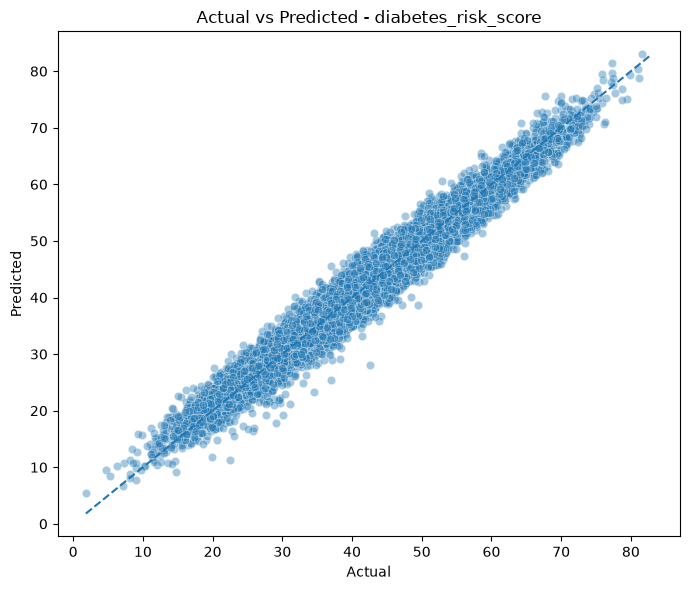

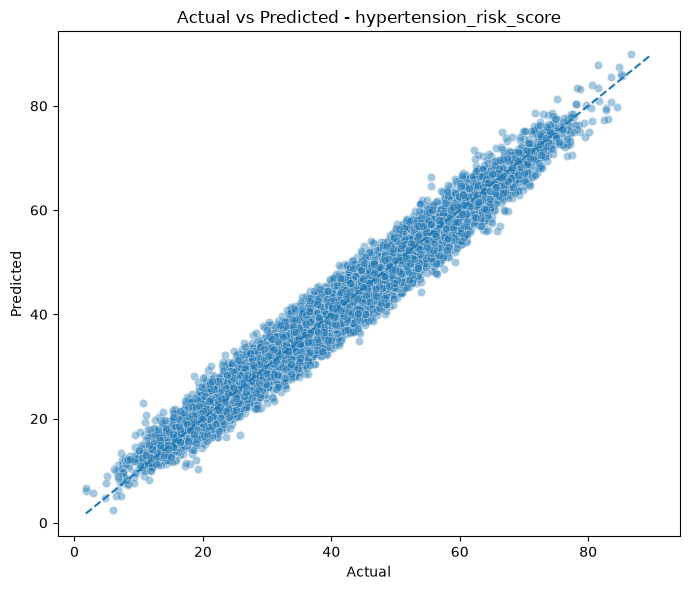

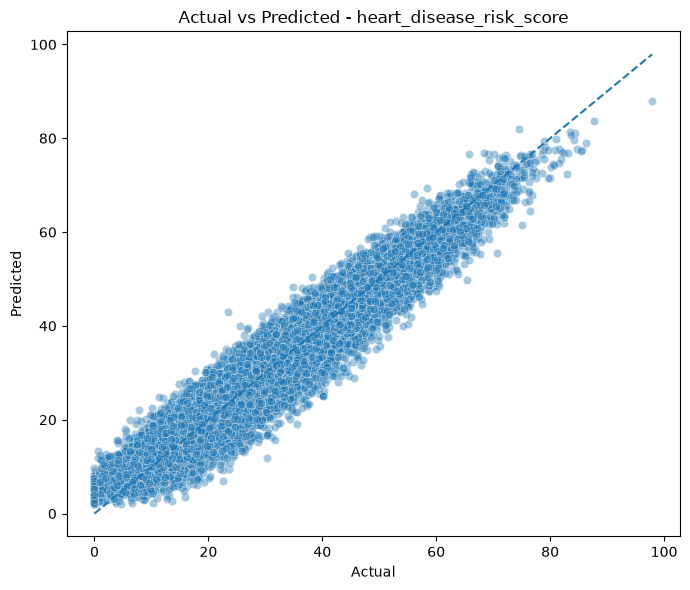

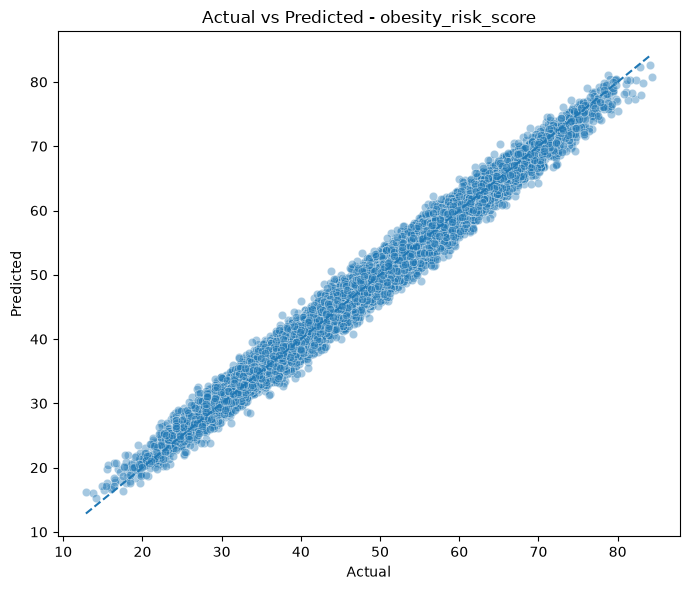

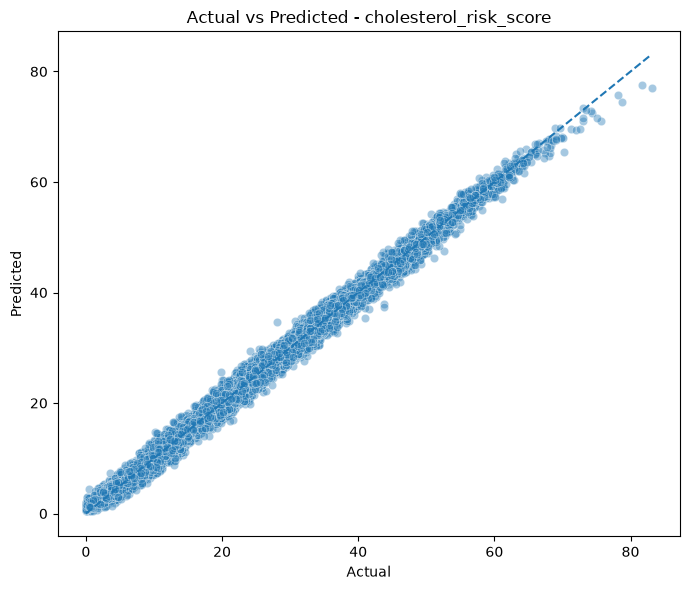

In [34]:
#Actual vs Predicted — all targets

for target in target_columns:

    actual = y_test[target].values
    predicted = best_model_predictions[target]

    plt.figure(figsize=(7, 6))

    sns.scatterplot(
        x=actual,
        y=predicted,
        alpha=0.4
    )

    min_value = min(
        actual.min(),
        predicted.min()
    )

    max_value = max(
        actual.max(),
        predicted.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.title(
        f"Actual vs Predicted - {target}"
    )

    plt.xlabel("Actual")
    plt.ylabel("Predicted")

    plt.tight_layout()
    plt.show()

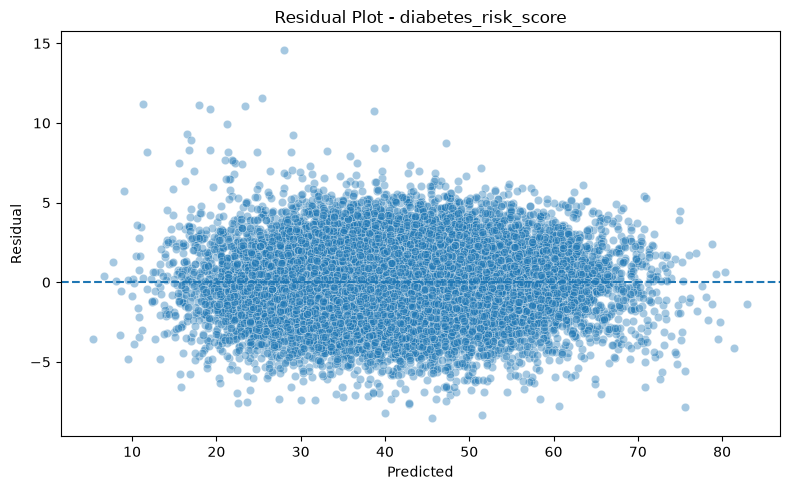

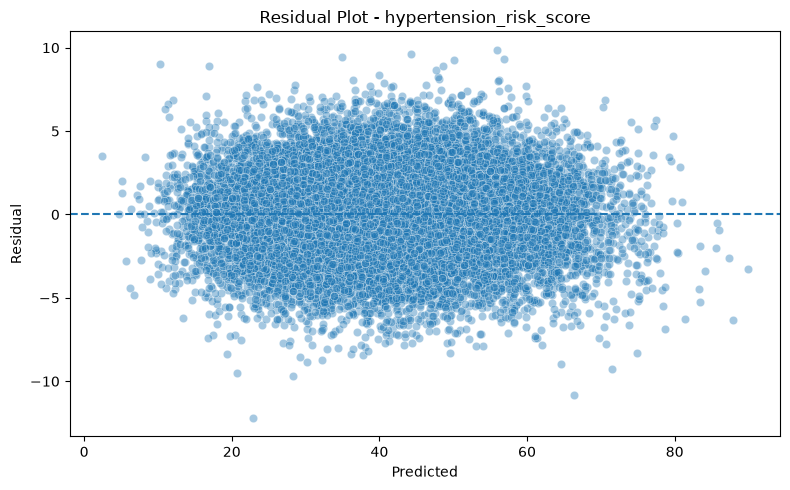

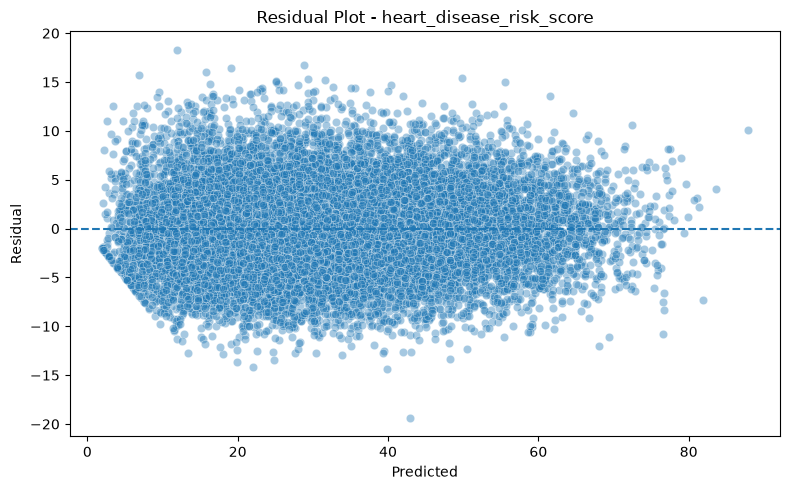

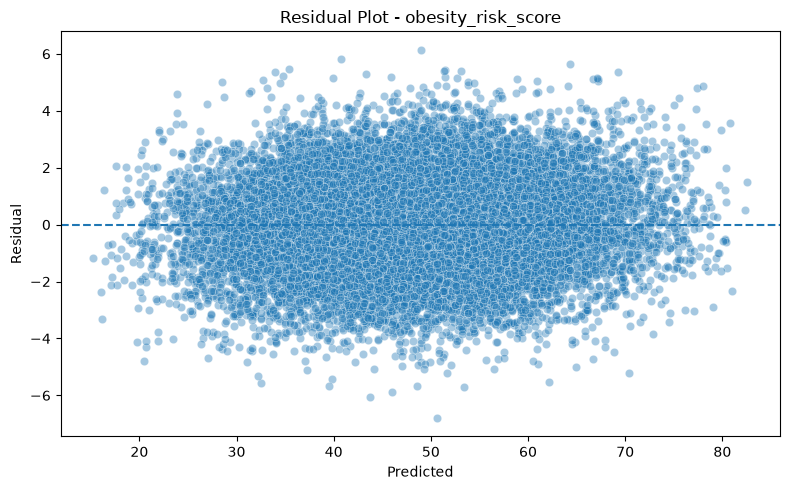

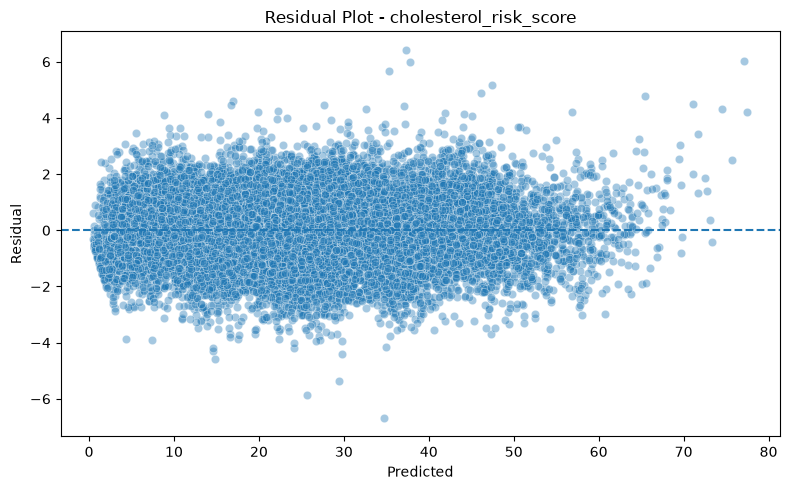

In [35]:
#Residual analysis

for target in target_columns:

    actual = y_test[target].values
    predicted = best_model_predictions[target]

    residuals = actual - predicted

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        x=predicted,
        y=residuals,
        alpha=0.4
    )

    plt.axhline(
        y=0,
        linestyle="--"
    )

    plt.title(
        f"Residual Plot - {target}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Residual")

    plt.tight_layout()
    plt.show()

In [36]:
#Check residual statistics

residual_summary = []

for target in target_columns:

    actual = y_test[target].values
    predicted = best_model_predictions[target]

    residuals = actual - predicted

    residual_summary.append({
        "Target": target,
        "Mean Residual": np.mean(residuals),
        "Std Residual": np.std(residuals),
        "Min Residual": np.min(residuals),
        "Max Residual": np.max(residuals)
    })

residual_summary_df = pd.DataFrame(
    residual_summary
)

residual_summary_df

,Target,Mean Residual,Std Residual,Min Residual,Max Residual
0,diabetes_risk_score,0.017404,2.170188,-8.526666,14.598934
1,hypertension_risk_score,-0.007493,2.533202,-12.208298,9.877601
2,heart_disease_risk_score,-0.041950,4.178627,-19.392625,18.304554
3,obesity_risk_score,-0.013807,1.592773,-6.798870,6.143666
4,cholesterol_risk_score,-0.006060,1.173339,-6.685414,6.428668


In [37]:
#Save evaluation results

os.makedirs(
    "../outputs/metrics",
    exist_ok=True
)

evaluation_df.to_csv(
    "../outputs/metrics/model_evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [38]:
#Save best model summary

best_models_df.to_csv(
    "../outputs/metrics/best_models_by_target.csv"
)

print("Best model summary saved successfully.")

Best model summary saved successfully.


In [39]:
#Save comparison tables

rmse_comparison.to_csv(
    "../outputs/metrics/rmse_comparison.csv"
)

mae_comparison.to_csv(
    "../outputs/metrics/mae_comparison.csv"
)

r2_comparison.to_csv(
    "../outputs/metrics/r2_comparison.csv"
)

print("Comparison tables saved successfully.")

Comparison tables saved successfully.


# Model Evaluation Summary

Five regression algorithms were evaluated for the five health risk
prediction targets.

The evaluation metrics used were:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

MAE and RMSE were interpreted such that lower values indicate better
performance, while higher R² values indicate better performance.

Model performance was evaluated separately for each target variable.

The best model for each risk score was selected primarily using RMSE,
while MAE and R² were also considered when interpreting model performance.

The selected models are documented in:

`outputs/metrics/best_models_by_target.csv`

The candidate models have not been replaced or modified during this
evaluation stage.

The selected models will be saved as final production models in the
next notebook.